In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dsno3 = xr.open_mfdataset('/ocean/atall/MOAD/rivers-climatology/bio/R201906_bioClim*.nc', concat_dim='time_counter', combine='nested')
dssil = xr.open_mfdataset('/ocean/atall/MOAD/rivers-climatology/bio/RPugetExp_bioClim*.nc', concat_dim='time_counter', combine='nested')
dscons = xr.open_dataset('/ocean/atall/MOAD/rivers-climatology/bio/R202101_bioConst.nc')


In [3]:
#Mass-balance budgets, from Johannessen et al. 2003, for:
#DOC: 380.10^6 kgC/year (Fraser river) + 150.10^6 kgC/year (Other rivers)
#POC: 170.10^6 kgC/year (Fraser river) + 50.10^6 kgC/year (Other rivers)
#Fresh water discharge: 115.5 10^9 m3/year (Fraser river) + 33.55 10^9 m3/year (other rivers)

#1kgC = 10^6mgC = 10^6x(1/12)x(1/6.6)mmolN = 12626 mmolN

#[Conc (kg/m3)] = F (kg/year) /Q (m3/year)
#[DON] = 45.33 mmolN/m3  , 19% of labile DON --- 8.5 mmolN/m3
#[PON] = 18.64 mmolN/m3 

In [4]:
dscons['don'] = dscons['nh4']-dscons['nh4']+45.33*0.19
dscons['pon'] = dscons['nh4']-dscons['nh4']+18.6*0.35
#dscons['pon'] = dscons['nh4']-dscons['nh4']+18.6*0.10

NH4 =  4.3
PON =  6.51
DON =  8.6127


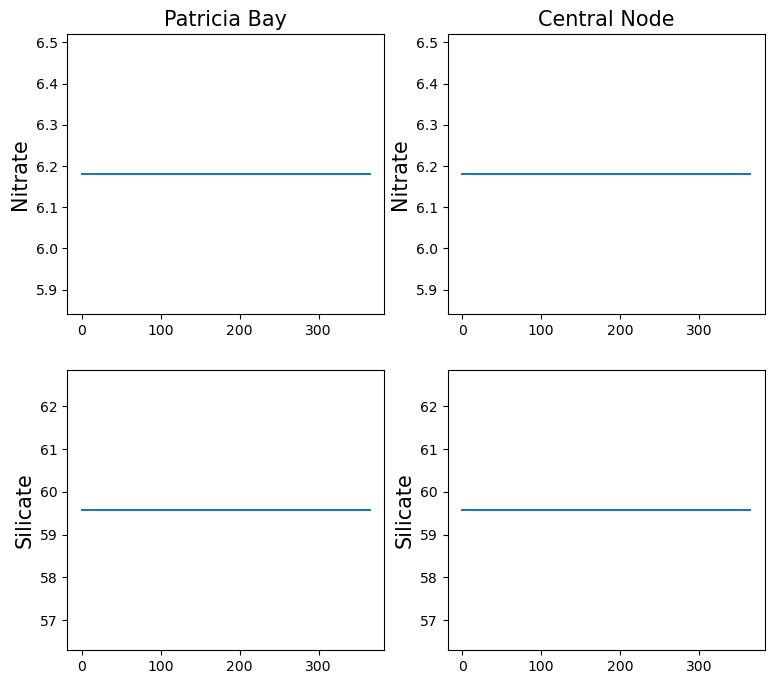

In [5]:
line, col = (2, 2)
fig, ax = plt.subplots(line, col, figsize=(9, 8))
place = list(['Patricia Bay','Central Node'])
ylabel = list(['Nitrate','Silicate','DON','PON'])
for j in range(0, col):
    if j==0:
        jj, ii = (353, 209)
    else:
        jj, ii = (423, 266)
    
    for i in range(0, line):
            if i==0:
                var = dsno3['no3'][:,jj,ii]
            elif i==1:
                var = dssil['sil'][:,jj,ii]

            ax[i,j].plot(var.time_counter, var)
            ax[i,j].set_ylabel(f'{ylabel[i]}',fontsize=15)
            ax[0,j].set_title(f'{place[j]}',fontsize=15)
            #ax[i,j].grid()
print('NH4 = ',np.array(dscons['nh4'][0,jj,ii]))
print('PON = ',np.array(dscons['pon'][0,jj,ii]))
print('DON = ',np.array(dscons['don'][0,jj,ii]))
xr.Dataset.to_netcdf(dscons,f'/ocean/atall/MOAD/rivers-climatology/bio/R202410_bioConst.nc')
#xr.Dataset.to_netcdf(dscons,f'/ocean/atall/MOAD/rivers-climatology/bio/R202410_bioConst_bis.nc')
